In [563]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# **Sintetización Monte Carlo de la silueta de un agujero negro con Ray Tracing (Aproximación Eikonal)**

**Por:** David Alejandro Pérez Múnera

En este notebook se sintetiza la imagen que vería un observador lejano de un agujero negro rodeado por un disco de acreción. Se usa *ray tracing inverso*: se lanzan rayos desde la pantalla del observador (plano $z-y$, en $x=-100$) hacia el agujero negro y, para cada uno, se calcula su trayectoria. Luego se comprueba si esa trayectoria toca el disco (el píxel se ilumina), cae al horizonte o escapa (el píxel queda oscuro). No se tendran en cuenta ecuaciones de movimiento de geometria diferencial, solo se tiene en cuenta la **aproximación Eikonal**. en esta aproximación los rayos de luz se tratan como si se propagaran a traves de un medio en el que la velocidad de la luz es inversamente proporcional a un indice de refraccion $n(\vec{r})=n(x,y)$. En esta aproximación el espacio-tiempo alrededor de un agujero negro se modela mediante un indice de refraccion radial:


$$
n(r)= \frac{1}{1-\frac{A}{r}}, \quad r=\sqrt{x^2 + y^2}
$$

Donde $A$ es una constante correspondiente al radio gravitacional del agujero negro. 

Los rayos de luz se curvan hacia el centro a medida que r → A. Es conveniente introducir un factor de corrección a este  ́ındice para lograr una mejor aproximación a lo predicho por la relatividad general, asi:

$$
corr = \left|1 - \frac{9}{8} (\frac{A}{r})^2\right|
$$

A continuacion se definen las funciones numericas:

In [564]:
rf = lambda x, y: np.sqrt(x**2 + y**2)

# indice de refraccion de aproximacion eikonal
nf = lambda x, y, rmax, eps: 1/ (1 - rmax / (rf(x, y)+ eps))

# Falctor de correccion
corrf = lambda x, y, rmax: np.abs(1 - 9/8 * (rmax/ rf(x, y))**2)


Dejaremos la siguiente celda donde se definiran los parametros geométricos de interes para la simulación.

In [565]:
# Para los rayos

N = 17000 # numero de posiciones iniciales a generar
R = 70 # radio sugerido
A = 10 # radio del agujero negro


# Para el disco de acrecion
Nd = 11000   # Numero de particulas en el disco
Rin = 15    # Radio interno del disco
Rext = 50   # Radio externo del disco

i_rot = 20 # Angulo de inclinacion del disco con respecto al eje x

Las ecuaciones que describen la trayectoria $(x, y)$ y la velocidad $(v_x, v_y)$ de un rayo en esta aproximación viene dada por: 

$$
\frac{dx}{dt} = \frac{v_x}{n(x, y)} \quad \wedge \quad \frac{dy}{dt} = \frac{v_y}{n(x,y)}
$$

y:

$$
\frac{d\, v_x}{dt} = \frac{\partial }{\partial x} n(x, y) \quad \wedge \quad \frac{d\,v_y}{dt} = \frac{\partial}{\partial y} n(x, y)
$$

In [566]:
# definimos las ecuaciones diferenciales que modelan la trayectoria de la luz

def refindex(x, y, A=10):
    eps = 1e-7

    r = rf(x, y)

    n = nf(x, y, A, eps)

    fac = corrf(x, y, A)

    nx = -fac * n**2 * A * x / (r + eps)**3
    ny = -fac * n**2 * A * y / (r + eps)**3

    return n, nx, ny


def flow_deriv(t, state, A=10):
    x, y, vx, vy = state

    n, nx, ny = refindex(x, y, A)

    deriv = np.zeros(4)

    deriv[0] = vx / n
    deriv[1] = vy / n
    deriv[2] = nx
    deriv[3] = ny

    return deriv


## **Simulación de montecarlo para posiciones iniciales en el plano $z-y$**

A continuación, generaremos puntos aleatorios uniformemente distribuidos en un circulo de radio $r$ ubicado en el plano coordenado $z-y$, los cuales corresponderan a puntos de una fuente de luz esférica, corresponderan a los valores iniciales. 


In [567]:
N = N # numero de posiciones iniciales a generar
R = R # radio sugerido

# Generamos posiciones iniciales aleatorias dentro de un círculo de radio R
theta = np.random.uniform(0, 2*np.pi, N)
rs = R * np.sqrt(np.random.uniform(0, 1, N))

# posiciones cartesianas en el plano y-z
y = rs * np.cos(theta)
z = rs * np.sin(theta)
x = np.zeros(N)  # eje x

# lo convertimos a coordenadas cilindricas
rs = np.sqrt(x**2 + y**2 + z**2)


**Visualizemos las posiciones iniciales generadas aleatoriamente**

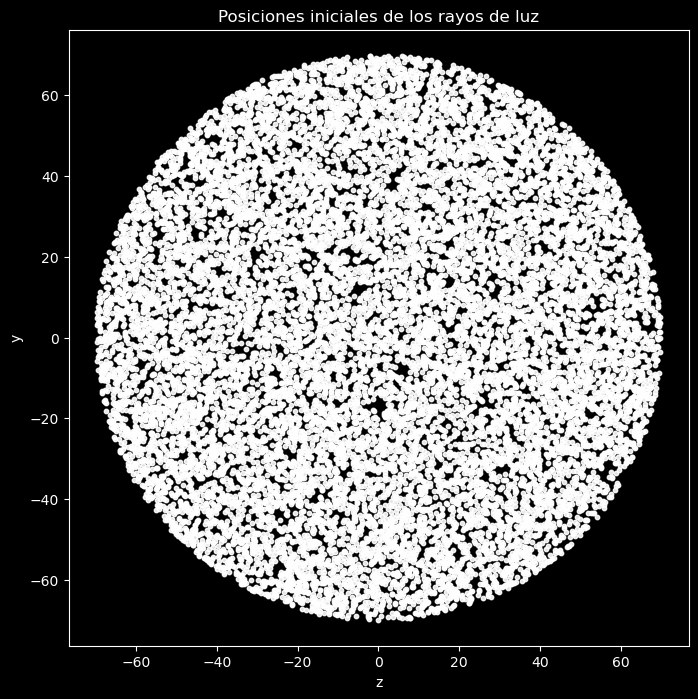

In [568]:
# visualizacion de los puntos en el plano

plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(z, y, s=10, c='white', alpha=0.9)
plt.title('Posiciones iniciales de los rayos de luz', color='white')
plt.xlabel('z', color='white')
plt.ylabel('y', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
#plt.savefig('imagenes_bacanas/posiciones_iniciales_aleatorias.png', dpi=300, bbox_inches='tight')
plt.show()

## **Integración de rayos en plano $x-y$**

Ya tenemos las distancias radiales a al centro del plano coordenado $y-z$. A continuacion vamos a simular una situacion en la que hay una fuente de luz en el plano $y-z$ alejado a una distancia $x=-100$ de un agujero negro. Vamos a ver desde la perspectiva del plano $x-y$ como se deforma la trayectoria de los rayos de luz que se desplazan a una velocidad $(\vec{v}_0 = [1, 0])$ en el plano $x-y$ debido a la presencia de este agujero negro. Para esto resolvemos las ecuaciones planteadas anteriormente.

**Asi, resolvemos la ecuación en la aproximación Eikonal para todos los rayos de luz.**

Aqui tomamos como condiciones iniciales para cada rayo de luz: 
- $x=-100$ 
- $y=r$ (Distancias radiales generadas aleatoriamente) 
- $v_x=1$ (Velocidad horizontal)
- $v_y= 0$ (Sin velocidad vertical)

Se integrara la trayectoria de los rayos de luz en intervalo de tiempo de $t \in [0, 400]$ con $\Delta t = 1$.


In [569]:
# inicializamos el proceso de integración para la aproximacion eikonal
x0, y0 = -100, rs
vx0, vy0 = 1, 0


# Definimos los tiempos de integración
tspan = [0, 400]
# array de tiempo con paso 1
ts = np.arange(tspan[0], tspan[1], 1)

Con esto, resolvemos numericamente la función `flow_deriv` usando `solve_ivp` de *scipy*. También, vamos a truncar la simulación para cada rayo cuando $r = A$ usando la opcion de `events` en `solve_ivp`; Esto debido a que alli diverge nuestro modelo para $n$ y significará que el agujero negro ha absorbido ese rayo de luz.

In [570]:
xs = []
ys = []
eventos = []

def event_horizon(t, state, A=10):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)

    return r - A  # radio del horizonte de eventos

event_horizon.terminal = True
event_horizon.direction = -1

for i in range(N):
    sol = solve_ivp(
        flow_deriv,
        tspan,
        np.array([x0, rs[i], vx0, vy0]),
        t_eval=ts,
        args=(A,),
        events=event_horizon
    )

    xs.append(sol.y[0])
    ys.append(sol.y[1])
    eventos.append(sol.t_events[0][0] if sol.t_events[0].size > 0 else np.nan)  # Guardamos el tiempo del evento o nan si no ocurrió

comprobacion_ext = np.zeros(N, dtype=bool)
for i in range(N):
    comprobacion_ext[i] = np.max(xs[i]) > 300

print("Número de rayos que se alejan extremadamente (x>300) del agujero negro son:", np.sum(comprobacion_ext))

Número de rayos que se alejan extremadamente (x>300) del agujero negro son: 0


**Graficamos la trayectoria de los rayos de luz**

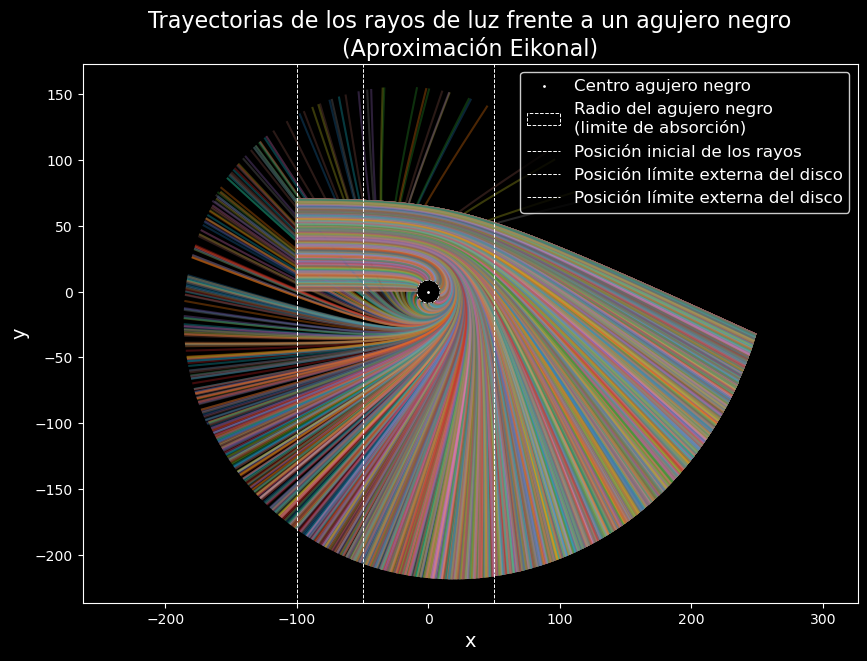

In [571]:
plt.figure(figsize=(10, 7), facecolor='black')


ax = plt.gca()
ax.set_facecolor('black')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
ax.set_aspect('equal', adjustable='box')

plt.scatter(0, 0, s=1, c='white', marker='o',
            label='Centro agujero negro', zorder=5)

circulo = plt.Circle((0, 0), 8.8, color='white', label='Radio del agujero negro\n(limite de absorción)',
                     fill=False, linestyle='--', linewidth=0.7)
ax.add_patch(circulo)

for i in range(N):
    plt.plot(xs[i], ys[i], alpha=0.3)

plt.title('Trayectorias de los rayos de luz frente a un agujero negro\n(Aproximación Eikonal)', fontsize=16, color='white')
plt.xlabel('x', fontsize=14, color='white')
plt.ylabel('y', fontsize=14, color='white')
plt.axvline(-100, color='white', linestyle='--', linewidth=0.7, label='Posición inicial de los rayos')
plt.axvline(-50, color='white', linestyle='--', linewidth=0.7, label='Posición límite externa del disco')
plt.axvline(50, color='white', linestyle='--', linewidth=0.7, label='Posición límite externa del disco')
plt.tick_params(colors='white')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.axis('equal')  
plt.legend(loc='upper right', fontsize=12, facecolor='black', edgecolor='white', labelcolor='white')
#plt.savefig('imagenes_bacanas/trayectorias.png', dpi=300, bbox_inches='tight')
plt.show()

In [572]:
eventos = np.array(eventos)  # Convertimos a un array de objetos para manejar listas de diferentes longitudes
eventos = eventos[~np.isnan(eventos)]  # Filtramos los eventos que no ocurrieron (NaN)


In [573]:
print(f"El agujero negro absorbió {len(eventos)} rayos de luz de los {N} rayos iniciales.")
print(f"El agujero negro absorbió un aproximado del {len(eventos)/N*100:.2f}% de los rayos de luz.")

El agujero negro absorbió 4528 rayos de luz de los 17000 rayos iniciales.
El agujero negro absorbió un aproximado del 26.64% de los rayos de luz.


## **Construcción de un disco inclinado**
Ahora, vamos a generar un disco con puntos, simulando la presencia de un disco de acreción delgado alrededor del agujero negro. 

Para esto vamos a generar un numero $N$ de posiciones iniciales aleatorias distribuidas uniformemente dentro de un anillo con radio interno $R_{in}$ y radio externo $R_{ext}$.

In [574]:
# definimos los parametros para la generacion del disco
Nd = Nd   # Numero de particulas en el disco
Rin = Rin    # Radio interno del disco
Rext = Rext   # Radio externo del disco

# generamos posiciones aleatorias para las particulas del disco
theta_d = np.random.uniform(0, 2*np.pi, Nd)
rds = np.sqrt(np.random.uniform(Rin**2, Rext**2, Nd)) 

# lo convertimos a coordenadas cartesianas
yd = rds * np.cos(theta_d)
zd = rds * np.sin(theta_d)



el espaciamiento promedio entre puntos del disco viene dado por:

$d_{ave} \approx \sqrt{\frac{\pi R_{out}^2}{N_d}}$

In [575]:
d_ave = np.sqrt(np.pi * (Rext**2) / Nd)  # distancia promedio entre particulas
print(f"La distancia promedio entre particulas del disco es: {d_ave:.2f}")

La distancia promedio entre particulas del disco es: 0.84


**Vizualizemos el disco generado en primera instancia:**

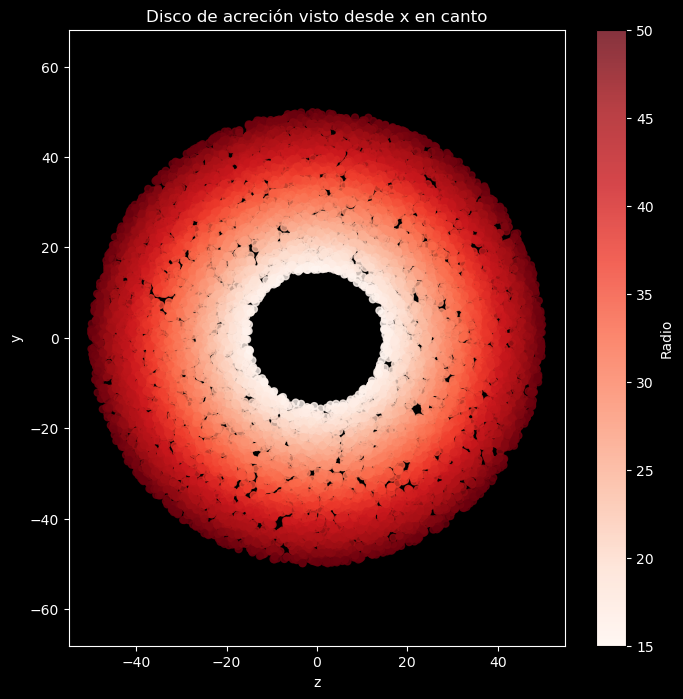

In [576]:
plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(zd, yd, s=25, c=rds, cmap='Reds',
            vmin=Rin, vmax=Rext, alpha=0.8)
cbar = plt.colorbar()
cbar.set_label('Radio', color='white')
cbar.ax.tick_params(colors='white')

plt.title('Disco de acreción visto desde x en canto', color='white')
plt.xlabel('z', color='white')
plt.ylabel('y', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
#plt.savefig('imagenes_bacanas/disco_acresión.png', dpi=300, bbox_inches='tight')
plt.show()


Vamos a inclinar el disco de acresión con respecto a nosotros a un ángulo $i$ con ayuda de la funcion para rotaciones (`scipy.spatial.transform.Rotation`).

In [577]:
from scipy.spatial.transform import Rotation as Rr

puntos = np.column_stack((np.zeros_like(yd), yd, zd))  # Convertimos a un array de Nx3
i_rot = i_rot # ángulo de rotación en grados
rot = Rr.from_euler('z', 90 - i_rot, degrees=True) #rotacion alrededor del eje z

puntos_rotados = rot.apply(puntos)

xd_rot = puntos_rotados[:, 0]
yd_rot = puntos_rotados[:, 1]
zd_rot = puntos_rotados[:, 2]

Veamos como cambia la perspectiva **graficando de nuevo el disco**

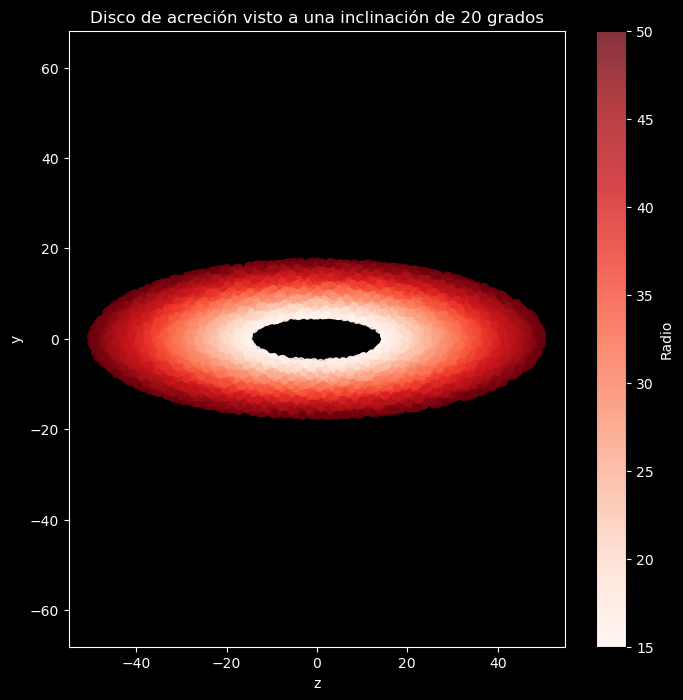

In [578]:
plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(zd_rot, yd_rot, s=25, c=rds, cmap='Reds',
            vmin=Rin, vmax=Rext, alpha=0.8)
cbar = plt.colorbar()
cbar.set_label('Radio', color='white')
cbar.ax.tick_params(colors='white')

plt.title(f'Disco de acreción visto a una inclinación de {i_rot} grados', color='white')
plt.xlabel('z', color='white')
plt.ylabel('y', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
#plt.savefig('imagenes_bacanas/disco_acresión_inclinado.png', dpi=300, bbox_inches='tight')
plt.show()

## **Intersecciones Rayo-Disco en 3D y Síntesis de la imagen**

Para determinar si un rayo contribuye a la imagen observada es necesario comprobar si intersecta al disco inclinado que simulamos anteriormente. Pa lograr esto, tenemos que rotar cada rayo al $\theta$ original.

A continuación se realiza una función que devuelva una matriz de rotación al rededor del eje $x$ en un ángulo $\theta$

In [579]:
# Se realiza una funcion de rotacion en el eje x
R_x_theta = lambda theta: np.array([[1, 0, 0],
                                    [0, np.cos(theta), -np.sin(theta)],
                                    [0, np.sin(theta), np.cos(theta)]])

Con nuestra función `R_x_theta` rotamos la trayectoria de cada rayo de luz y comprobamos si intersecta con el disco de acresión.

In [580]:
# A continuacion, rotamos cada trayectoria de los rayos de luz en el eje x para cada uno de los N rayos
zs_rotadas = []
ys_rotadas = []
xs_rotadas = []

for i in range(N):
    trayectoria = np.column_stack((xs[i], ys[i], np.zeros_like(xs[i])))
    trayectoria_rotada = R_x_theta(theta[i]).dot(trayectoria.T).T   # theta0[i], en radianes
    xs_rotadas.append(trayectoria_rotada[:, 0])
    ys_rotadas.append(trayectoria_rotada[:, 1])
    zs_rotadas.append(trayectoria_rotada[:, 2])



Comprobamos que la rotación es correcta comparando los valores inicales rotados con los valores iniciales

In [581]:
print(xs_rotadas[0][0], ys_rotadas[0][0], zs_rotadas[0][0])
print(-100, y[0], z[0])  
# Comprobamos que la rotacion es correcta para el primer rayo
print("Se comprueba que la rotación es correcta para el primer rayo: ", np.allclose(xs_rotadas[0][0], -100) and np.allclose(ys_rotadas[0][0], y[0]) and np.allclose(zs_rotadas[0][0], z[0]))

-100.0 33.849501102823154 6.9832000168389445
-100 33.849501102823154 6.9832000168389445
Se comprueba que la rotación es correcta para el primer rayo:  True


Ahora, realizamos la comprobación de que el rayo interseca el disco de acresión.

Para esto, implementaremos una función que optimiza el cálculo de distancias para cada rayo de luz (`scipy.spatial.cKDTree`) el cual ayuda a comparar distancias de una manera mucho mas optima a nivel computacional.

El método `cKDTree(puntos_comparacion).query(trayectoria, distance_upperbound=d_avec)` busca los vecinos más cercanos de cada punto del rayo a una distancia maxima de `d_ave`; si no hay ninguno a menos de `d_ave`, devuelve `dist = inf`.

In [582]:
from scipy.spatial import cKDTree

def intersecta_disco(xs, ys, zs, puntos_disco, d_ave):
    """
    Esta funcion, para cada rayo, devuelve el radio (respecto al agujero negro) del punto del
    disco que golpea, o -999 si no lo golpea.
    """

    N = len(xs)
    radio_impacto = np.full(N, -999.0)
    arbol = cKDTree(puntos_disco)            # se construye una sola vez

    for i in range(N):
        puntos = np.column_stack((xs[i], ys[i], zs[i]))

        # buscamos los puntos del rayo que están cerca del disco
        dist, indices = arbol.query(puntos, distance_upper_bound=d_ave)
        golpes = np.where(np.isfinite(dist))[0] # se extraen las distancias finitas (golpes) de los puntos del rayo con el disco

        if golpes.size > 0:
            primero = golpes[0]              # primer impacto a lo largo del rayo
            radio_impacto[i] = np.linalg.norm(puntos_disco[indices[primero]])

    return radio_impacto


# Usando la funcion anterior, obtenemos el radio del disco que golpea cada rayo
distancias_interseccion = intersecta_disco(xs_rotadas, ys_rotadas, zs_rotadas, puntos_rotados, d_ave)

Teniendo los radios de interseccion de los rayos, contemos cuantos rayos vienen del disco de acresion y cuantos no lo tocan.

In [583]:
golpeo = distancias_interseccion > 0
print(f"{golpeo.sum()} de {N} rayos golpean el disco")

5039 de 17000 rayos golpean el disco


Ahora, grafiquemos las posiciones iniciales de rayos del primer inciso pero estavez coloreamos las posiciones iniciales de los rayos que llegan a interceptar el disco de acreción.

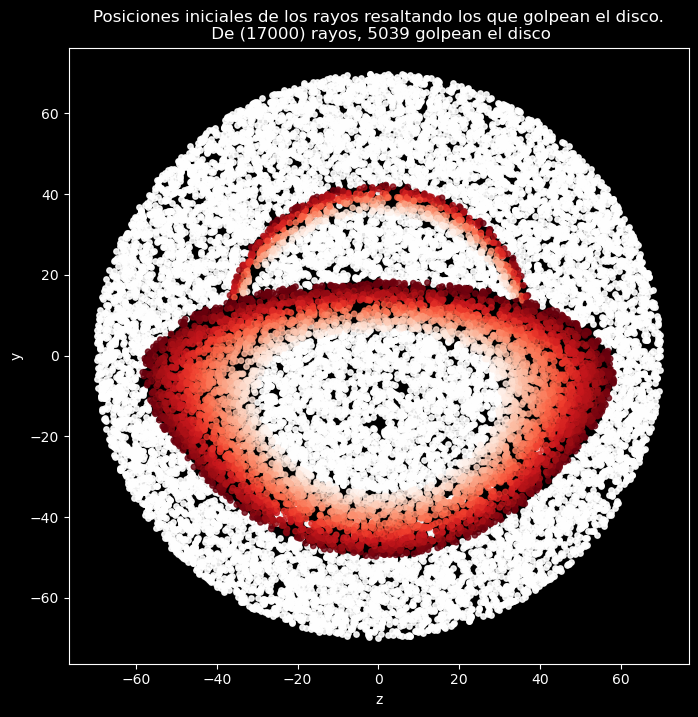

In [584]:
plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(z[~golpeo], y[~golpeo], s=15, c='white', alpha=0.9)
plt.scatter(z[golpeo], y[golpeo], s=15, c=distancias_interseccion[golpeo], cmap='Reds',
            vmin=Rin, vmax=Rext, alpha=0.8)









plt.title(f'Posiciones iniciales de los rayos resaltando los que golpean el disco.\n De ({N}) rayos, {golpeo.sum()} golpean el disco', color='white')
plt.xlabel('z', color='white')
plt.ylabel('y', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
#plt.savefig('imagenes_bacanas/rayos_golpean_disco.png', dpi=300, bbox_inches='tight')
plt.show()

**Gráfica final.** A continuación se grafican únicamente las posiciones iniciales $(y_0, z_0)$ de los rayos que intersecan el disco de acreción. La función `intersecta_disco` devuelve, para cada rayo, el radio (medido desde el agujero negro) al que impacta el disco, y usamos ese valor para construir un mapa de calor: los tonos blancos corresponden a impactos cercanos al agujero negro, y los tonos rojos a impactos más alejados, cerca del borde exterior del disco.

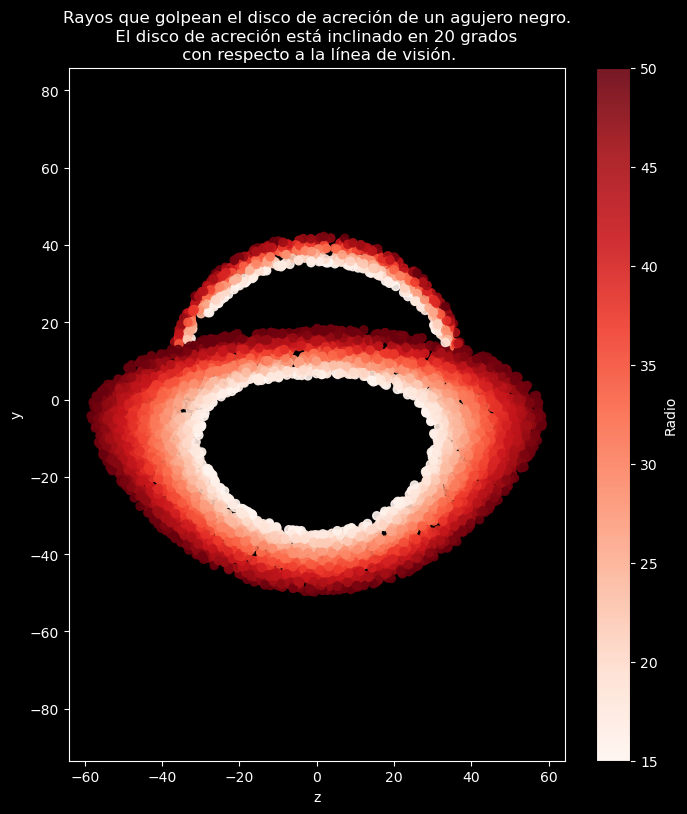

In [585]:
plt.figure(figsize=(8, 9), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter( z[golpeo], y[golpeo], s=35, c=distancias_interseccion[golpeo], cmap='Reds',
            vmin=Rin, vmax=Rext, alpha=0.9)
cbar = plt.colorbar()
cbar.set_label('Radio', color='white')
cbar.ax.tick_params(colors='white')

plt.title(f'Rayos que golpean el disco de acreción de un agujero negro.\n El disco de acreción está inclinado en {i_rot} grados \n con respecto a la línea de visión.', color='white')
plt.xlabel('z', color='white')
plt.ylabel('y', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
plt.savefig(f'imagenes_bacanas/BH_images/agujero_negro_{i_rot}.png', dpi=300, bbox_inches='tight')
plt.show()


A continuación, se realiza el mismo procedimiento para simular como se veria una imagen si el disco de acreción del agujero negro se encuentra en una inclinacion de 45° y 70°.

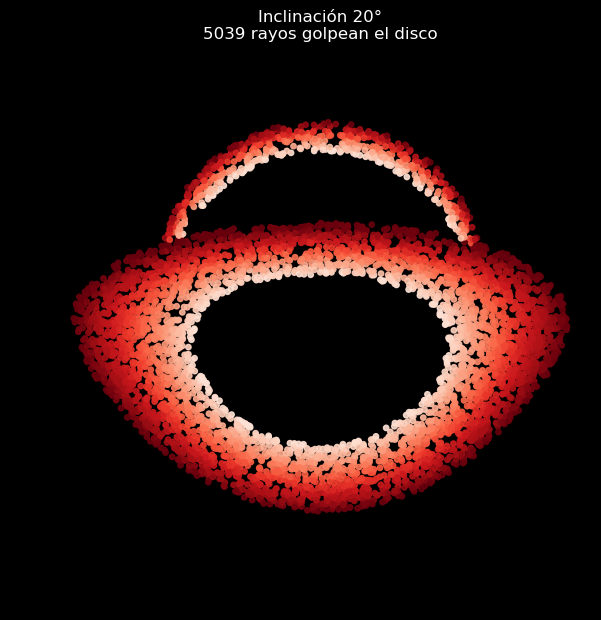

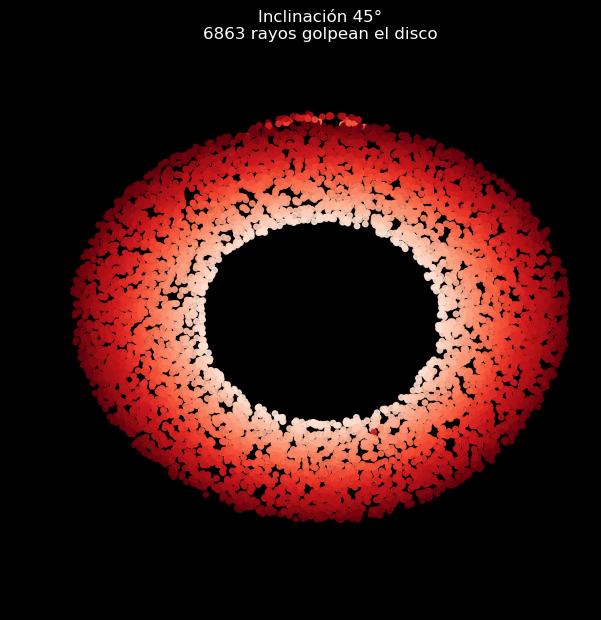

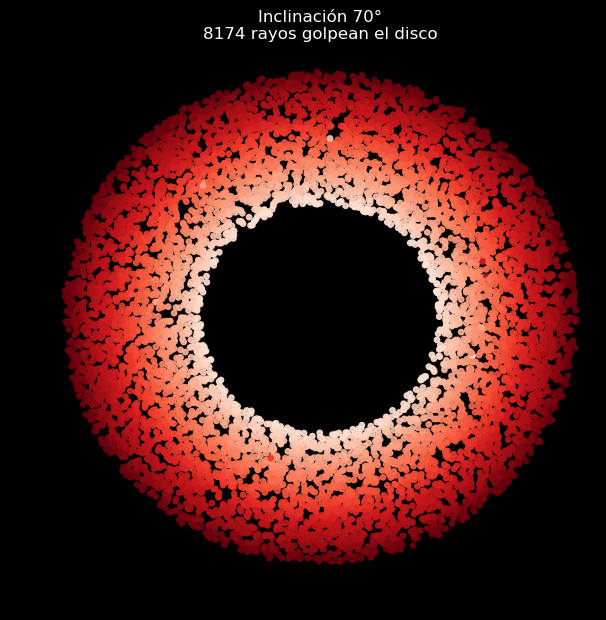

In [586]:
for inc in [20, 45, 70]:
    disco = Rr.from_euler('z',90 - inc, degrees=True).apply(puntos)
    radio_impacto = intersecta_disco(xs_rotadas, ys_rotadas, zs_rotadas, disco, d_ave)
    golpeo_inc = radio_impacto > 0

    plt.figure(figsize=(7, 7), facecolor='k')
    ax = plt.gca(); ax.set_facecolor('k')
    plt.scatter(z[golpeo_inc], y[golpeo_inc], c=radio_impacto[golpeo_inc],
                cmap='Reds', vmin=0.7*Rin, vmax=Rext, s=15, alpha=0.9)
    plt.title(f'Inclinación {inc}°\n{golpeo_inc.sum()} rayos golpean el disco', color='w')
    plt.axis('equal')

Vemos que a medida de que aumenta el angulo de inclinación del disco de acresion cambia con respecto a la linea de visión, mas rayos de luz impactan el rayo. Tambien es notable ver la forma "extraña" que llega a tomar la imagen que se vuelve poco intuitiva.